# Logloss

**Logloss** (logarytmiczna funkcja straty), znana też jako **logarytmiczna entropia krzyżowa** (*logarithmic loss* albo *binary cross-entropy*), to funkcja oceniająca jakość **predykcji probabilistycznych** w problemach klasyfikacji binarnej (lub wieloklasowej).

---

**Definicja (dla klasyfikacji binarnej):**

Dla każdego przykładu (rekordu), jeśli model przewiduje prawdopodobieństwo przynależności do klasy pozytywnej (`p`) i prawdziwa etykieta (`y`) to `0` lub `1`, logloss definiuje się jako:

$$
\text{LogLoss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \cdot \log(p_i) + (1 - y_i) \cdot \log(1 - p_i) \right]
$$

* $N$ – liczba próbek
* $y_i$ – prawdziwa etykieta (0 lub 1)
* $p_i$ – przewidywane prawdopodobieństwo klasy 1

---

**Co mierzy logloss?**

* Kara za bycie **pewnym i w błędzie**.
* **Im bliżej wartości progowej (np. 0.5), tym mniejsza kara**.
* **Im mniejszy logloss, tym lepiej** – oznacza to, że model dobrze szacuje prawdopodobieństwa.

---

**Przykład:**

* Jeśli prawdziwa klasa to `1`, a model przewiduje `p=0.9` → bardzo dobrze (niski logloss).
* Jeśli prawdziwa klasa to `1`, a model przewiduje `p=0.01` → bardzo źle (duży logloss).
* Dobrze skalibrowany model probabilistyczny będzie miał niski logloss.

---

Załóżmy:

* Prawdziwa etykieta (czyli co się **naprawdę stało**) to `1` – czyli klient **kupił lokatę**.
* Model przewiduje prawdopodobieństwo `p`, że klient kupi lokatę.

Wzór dla **logloss w takim przypadku** wygląda tak:

$$
\text{Logloss} = -\log(p)
$$

Dlaczego tak? Bo skoro **prawdziwa odpowiedź to 1**, to tylko liczy się ten kawałek wzoru:

$$
-y \cdot \log(p) = -1 \cdot \log(p) = -\log(p)
$$

---

**Przykład 1**: model dobrze przewiduje

* Prawdziwa klasa: `1`
* Przewidywane prawdopodobieństwo: `p = 0.9` (czyli 90%)
* Liczymy:

$$
\text{Logloss} = -\log(0.9) \approx 0.105
$$

**Niska kara** – bo model był **blisko prawdy i pewny**.

---

**Przykład 2**: model bardzo się myli

* Prawdziwa klasa: `1`
* Przewidywane prawdopodobieństwo: `p = 0.01` (czyli tylko 1%)
* Liczymy:

$$
\text{Logloss} = -\log(0.01) \approx 4.605
$$

**Ogromna kara** – model był **pewny, że klient NIE kupi**, a klient **kupił**.

---

**Przykład 3**: model niepewny

* Prawdziwa klasa: `1`
* Przewidywane prawdopodobieństwo: `p = 0.5`
* Liczymy:

$$
\text{Logloss} = -\log(0.5) \approx 0.693
$$

**Średnia kara** – model **był niepewny**.

---

**Różnica w stosunku do accuracy:**

* **Accuracy** mówi, czy model trafił w klasę.
* **Logloss** mówi, **jak bardzo był pewny** swojej decyzji i czy miał rację.

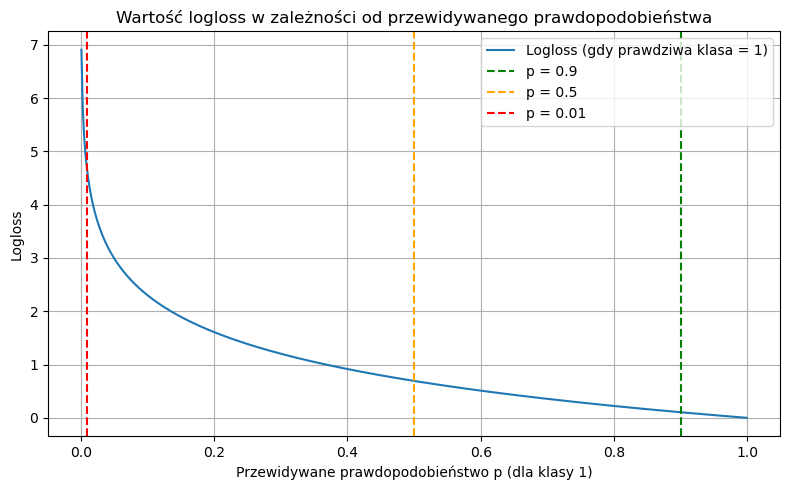

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Zakres prawdopodobieństw od 0.001 do 0.999 (żeby uniknąć log(0))
p_values = np.linspace(0.001, 0.999, 500)
logloss_values = -np.log(p_values)

# Tworzenie wykresu
plt.figure(figsize=(8, 5))
plt.plot(p_values, logloss_values, label="Logloss (gdy prawdziwa klasa = 1)")
plt.axvline(x=0.9, color='green', linestyle='--', label='p = 0.9')
plt.axvline(x=0.5, color='orange', linestyle='--', label='p = 0.5')
plt.axvline(x=0.01, color='red', linestyle='--', label='p = 0.01')
plt.xlabel("Przewidywane prawdopodobieństwo p (dla klasy 1)")
plt.ylabel("Logloss")
plt.title("Wartość logloss w zależności od przewidywanego prawdopodobieństwa")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Na wykresie widzisz, jak **logloss rośnie**, gdy przewidywane prawdopodobieństwo dla klasy 1 (`p`) jest **niskie**, a rzeczywista klasa to właśnie **1**.

* Dla `p = 0.9` – kara jest mała (model się prawie nie myli).
* Dla `p = 0.5` – kara jest umiarkowana (model niepewny).
* Dla `p = 0.01` – kara jest ogromna (model bardzo się mylił i był tego pewny).

To pokazuje, dlaczego **logloss docenia dobre probabilistyczne przewidywania** i **karze nadmierną pewność, jeśli się mylisz**.